# ------------------BLACK-76 MODEL FOR COMMODITY--------------

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq

def black_76_price(F, K, T, r, sigma, option_type='call'):
    """
    Standard Black '76 Pricing for Futures/Commodities
    """
    # Standard d1/d2 for Black 76 (Notice no 'r' in d1)
    d1 = (np.log(F / K) + (0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    discount = np.exp(-r * T)

    if option_type.lower() == 'call':
        price = discount * (F * norm.cdf(d1) - K * norm.cdf(d2))
    else:
        price = discount * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

    return price

In [ ]:
def black_76_iv(market_price, F, K, T, r, option_type='call'):
    def objective_function(sigma):
        return black_76_price(F, K, T, r, sigma, option_type) - market_price
    try:
        # Solving for sigma (Implied Volatility)
        return brentq(objective_function, 1e-6, 5.0)
    except ValueError:
        return np.nan

def black_76_greeks(F, K, T, r, sigma, option_type='call'):
    d1 = (np.log(F / K) + (0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    discount = np.exp(-r * T)

    # Delta
    delta = discount * norm.cdf(d1) if option_type == 'call' else -discount * norm.cdf(-d1)

    # Gamma
    gamma = (discount * norm.pdf(d1)) / (F * sigma * np.sqrt(T))

    # Vega (Change in price for 1% change in Vol)
    vega = (F * discount * norm.pdf(d1) * np.sqrt(T)) / 100

    # Theta (Daily decay)
    theta_term1 = -(F * discount * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
    if option_type == 'call':
        theta_term2 = r * K * discount * norm.cdf(d2) - r * F * discount * norm.cdf(d1)
    else:
        theta_term2 = -r * K * discount * norm.cdf(-d2) + r * F * discount * norm.cdf(-d1)
    theta = (theta_term1 + theta_term2) / 365

    return delta, gamma, vega, theta

In [ ]:
# --- INPUTS FROM BROKER ---
# Instrument: MCX Commodity Futures Option (live data, exact contract not recorded)
# Note: Real market prices fetched from broker terminal at time of analysis
F = 5819.0       # Current Futures Price
K = 5700.0       # Strike Price
T = 0.027        # Time to Expiry (years) ~ 10 days
r = 0.05         # Risk-free rate (5% — RBI repo rate)
mkt_p = 274.20   # Market Price from Broker

# --- CALCULATIONS ---
iv = black_76_iv(mkt_p, F, K, T, r, 'call')
delta, gamma, vega, theta = black_76_greeks(F, K, T, r, iv, 'call')

# --- DISPLAY ---
print("="*35)
print("  BLACK '76 COMMODITY ANALYSIS  ")
print("="*35)
print(f"Underlying (F):    {F:>10.2f}")
print(f"Market Price:      {mkt_p:>10.2f}")
print(f"Implied Vol (IV):  {iv*100:>10.2f}%")
print("-" * 35)
print(f"Delta:             {delta:>10.4f}")
print(f"Gamma:             {gamma:>10.6f}")
print(f"Vega (1% move):    {vega:>10.4f}")
print(f"Theta (per day):   {theta:>10.4f}")
print("="*35)

  BLACK '76 COMMODITY ANALYSIS  
Underlying (F):       5819.00
Market Price:          274.20
Implied Vol (IV):       55.57%
-----------------------------------
Delta:                 0.6063
Gamma:               0.000723
Vega (1% move):        3.6711
Theta (per day):     -10.3875


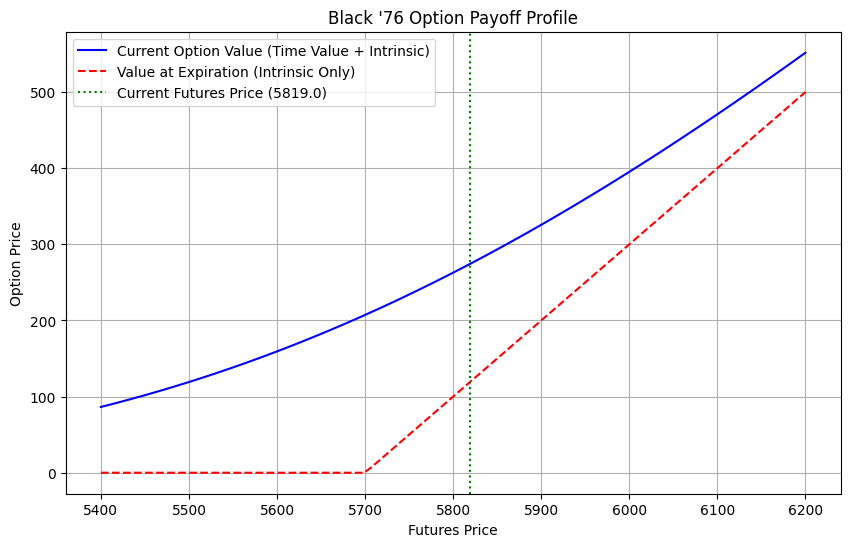

In [ ]:
import matplotlib.pyplot as plt

# Generate a range of futures prices around your current price (5819)
fs = np.linspace(5400, 6200, 100)
prices = [black_76_price(f, K, T, r, iv, 'call') for f in fs]

# Calculate Intrinsic Value (Value at expiration)
intrinsic = [max(0, f - K) for f in fs]

plt.figure(figsize=(10, 6))
plt.plot(fs, prices, label='Current Option Value (Time Value + Intrinsic)', color='blue')
plt.plot(fs, intrinsic, label='Value at Expiration (Intrinsic Only)', linestyle='--', color='red')
plt.axvline(F, color='green', linestyle=':', label=f'Current Futures Price ({F})')
plt.title("Black '76 Option Payoff Profile")
plt.xlabel("Futures Price")
plt.ylabel("Option Price")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =====================================================================
# SANITY CHECK — PUT-CALL PARITY
# =====================================================================
# Black '76 rule: Call - Put = (F - K) * e^(-rT)
# If this holds, our pricing model is correct.
# =====================================================================

call_price = black_76_price(F, K, T, r, iv, 'call')
put_price  = black_76_price(F, K, T, r, iv, 'put')

lhs   = call_price - put_price
rhs   = (F - K) * np.exp(-r * T)
error = abs(lhs - rhs)

print('='*40)
print('  PUT-CALL PARITY CHECK')
print('='*40)
print(f'  Call Price      : {call_price:>8.4f}')
print(f'  Put Price       : {put_price:>8.4f}')
print(f'  C - P           : {lhs:>8.4f}')
print(f'  (F-K)*e^(-rT)   : {rhs:>8.4f}')
print(f'  Error           : {error:>8.2e}')
print('-'*40)
if error < 1e-8:
    print('  PASSED — Model is correct')
else:
    print('  FAILED — Check implementation')
print('='*40)

  PUT-CALL PARITY CHECK
  Call Price      : 274.2000
  Put Price       : 155.3605
  C - P           : 118.8395
  (F-K)*e^(-rT)   : 118.8395
  Error           : 4.83e-13
----------------------------------------
  PASSED — Model is correct
